# **Miniproyecto Lending Club Loan Data**

## **Analisis Exploratorio**

### **Contexto**

Lending Club es una plataforma financiera estadounidense que realiza préstamos personales bajo el modelo (P2P), donde inversionistas financian directamente las solicitudes de crédito de los clientes. Esta base de datos contiene los préstamos aprobados por la plataforma entre 2007 y 2020, donde se tiene cada uno de los detalles importantes de sus clientes y su comportamiento crediticio .

### **Planteamiento del problema**

El crecimiento de las plataformas de préstamos digitales  durante los ultomso años ha obligado a estaos servicios financieros a evaluar los riesgos crediticios de manera precisa y escalable. Debido a esto, Lending Club enfrenta el desafío de identificar qué préstamos tienen alta probabilidad de incumplimiento  antes de ser otorgados. Una mala evaluación del riesgo puede generar  pérdidas significativas tanto para la plataforma como para los usuarios. En este contexto, surge la necesidad de construir un modelo predictivo, a partir de las características del solicitante y del préstamo, y se pueda anticipar si se va a pagar el credito o no.

### **Objetivos y justificación**

#### **Objetivo General**

Construir y comparar modelos de clasificación supervisada para predecir el incumplimiento en el pago de préstamos que son emitidos por Lending Club, evaluando el desempeño de scikit-learn frente a PySpark e incorporando el metodo LIME.


#### **Objetivos específicos**

- Realizar un análisis exploratorio del dataset para comprender la distribución de las variables y la variable objetivo
- Preprocesar los datos aplicando codificación, escalado y división estratificada
- Entrenar un modelo Random Forest con optimización de hiperparámetros en scikit-learn y PySpark
- Comparar métricas de desempeño 
- Interpretar predicciones individuales mediante LIME

#### **Justificación**
La predicción del riesgo crediticio es uno de los problemas más relevantes en la industria financiera. Es importante contar con modelos precisos que ayuda a tener mayor informacion en las tomas de decisiones y reducir posibles pérdidas. Adicionalmente, la comparación entre scikit-learn y PySpark aporta valor práctico al evaluar qué modelo es más adecuado según el volumen de datos y sus caracteristicas.

### **Descripcion de variables**



In [1]:
import pandas as pd

variables = [
    ("id", "Identificador único del préstamo en la plataforma Lending Club", "Numérica"),
    ("member_id", "Identificador único del miembro solicitante del préstamo", "Numérica"),
    ("loan_amnt", "Monto total solicitado por el prestatario en dólares", "Numérica"),
    ("funded_amnt", "Monto total comprometido para el préstamo hasta la fecha", "Numérica"),
    ("funded_amnt_inv", "Monto total comprometido por los inversionistas para ese préstamo", "Numérica"),
    ("term", "Plazo del préstamo en meses (36 o 60 meses)", "Categórica"),
    ("int_rate", "Tasa de interés anual asignada al préstamo expresada en porcentaje", "Numérica"),
    ("installment", "Cuota mensual que debe pagar el prestatario si el préstamo es financiado", "Numérica"),
    ("grade", "Calificación de riesgo asignada por Lending Club al préstamo (A, B, C, D, E, F, G)", "Categórica"),
    ("sub_grade", "Subclasificación más detallada dentro de cada grado de riesgo", "Categórica"),
    ("emp_title", "Cargo o título del empleo del solicitante", "Categórica"),
    ("emp_length", "Años de antigüedad laboral del solicitante (0 a 10 años)", "Categórica"),
    ("home_ownership", "Tipo de tenencia de vivienda del solicitante (propia, hipotecada, arrendada, entre otras)", "Categórica"),
    ("annual_inc", "Ingreso anual reportado por el solicitante en dólares", "Numérica"),
    ("verification_status", "Indica si el ingreso del solicitante fue verificado por Lending Club", "Categórica"),
    ("issue_d", "Fecha en que el préstamo fue emitido", "Fecha"),
    ("loan_status", "Estado actual del préstamo. Es la variable objetivo del modelo", "Categórica"),
    ("pymnt_plan", "Indica si el prestatario tiene un plan de pago activo (s/n)", "Categórica"),
    ("url", "URL del préstamo en la plataforma Lending Club", "Texto"),
    ("desc", "Descripción textual del préstamo proporcionada por el solicitante", "Texto"),
    ("purpose", "Propósito declarado del préstamo (consolidación de deudas, mejoras del hogar, educación, médico, etc.)", "Categórica"),
    ("title", "Título del préstamo proporcionado por el solicitante", "Texto"),
    ("zip_code", "Primeros tres dígitos del código postal del solicitante", "Categórica"),
    ("addr_state", "Estado de residencia del solicitante en Estados Unidos", "Categórica"),
    ("dti", "Relación deuda-ingreso del solicitante", "Numérica"),
    ("delinq_2yrs", "Número de veces que el solicitante tuvo mora de más de 30 días en los últimos 2 años", "Numérica"),
    ("earliest_cr_line", "Fecha de apertura de la primera línea de crédito del solicitante", "Fecha"),
    ("fico_range_low", "Límite inferior del rango de puntaje crediticio FICO al momento de la solicitud", "Numérica"),
    ("fico_range_high", "Límite superior del rango de puntaje crediticio FICO al momento de la solicitud", "Numérica"),
    ("inq_last_6mths", "Número de consultas al buró de crédito realizadas en los últimos 6 meses", "Numérica"),
    ("mths_since_last_delinq", "Meses transcurridos desde la última mora del solicitante", "Numérica"),
    ("mths_since_last_record", "Meses transcurridos desde el último registro público negativo del solicitante", "Numérica"),
    ("open_acc", "Número de líneas de crédito activas del solicitante", "Numérica"),
    ("pub_rec", "Número de registros públicos negativos del solicitante (quiebras, embargos, etc.)", "Numérica"),
    ("revol_bal", "Saldo total de crédito revolvente del solicitante en dólares", "Numérica"),
    ("revol_util", "Porcentaje de utilización del crédito revolvente disponible", "Numérica"),
    ("total_acc", "Número total de líneas de crédito en el historial del solicitante", "Numérica"),
    ("initial_list_status", "Estado inicial de publicación del préstamo en la plataforma (w: whole, f: fractional)", "Categórica"),
    ("out_prncp", "Saldo de capital pendiente de pago del préstamo", "Numérica"),
    ("out_prncp_inv", "Saldo de capital pendiente correspondiente a la porción financiada por inversionistas", "Numérica"),
    ("total_pymnt", "Total de pagos recibidos hasta la fecha, incluyendo capital e intereses", "Numérica"),
    ("total_pymnt_inv", "Total de pagos recibidos por los inversionistas hasta la fecha", "Numérica"),
    ("total_rec_prncp", "Capital total recuperado hasta la fecha", "Numérica"),
    ("total_rec_int", "Intereses totales recuperados hasta la fecha", "Numérica"),
    ("total_rec_late_fee", "Cargos por mora recuperados hasta la fecha", "Numérica"),
    ("recoveries", "Monto recuperado tras declararse el préstamo en default", "Numérica"),
    ("collection_recovery_fee", "Comisión cobrada por la gestión de cobro del préstamo en default", "Numérica"),
    ("last_pymnt_d", "Fecha del último pago recibido", "Fecha"),
    ("last_pymnt_amnt", "Monto del último pago recibido", "Numérica"),
    ("next_pymnt_d", "Fecha programada del próximo pago", "Fecha"),
    ("last_credit_pull_d", "Fecha de la última consulta al buró de crédito realizada por Lending Club", "Fecha"),
    ("last_fico_range_high", "Límite superior del puntaje FICO más reciente del solicitante", "Numérica"),
    ("last_fico_range_low", "Límite inferior del puntaje FICO más reciente del solicitante", "Numérica"),
    ("collections_12_mths_ex_med", "Número de cobros judiciales en los últimos 12 meses, excluyendo deudas médicas", "Numérica"),
    ("mths_since_last_major_derog", "Meses transcurridos desde la última calificación crediticia negativa grave", "Numérica"),
    ("policy_code", "Código de política de préstamo disponible públicamente (1 = disponible, 2 = no disponible)", "Categórica"),
    ("application_type", "Indica si la solicitud es individual o conjunta", "Categórica"),
    ("annual_inc_joint", "Ingreso anual combinado de ambos solicitantes en caso de solicitud conjunta", "Numérica"),
    ("dti_joint", "Relación deuda-ingreso combinada en solicitudes conjuntas", "Numérica"),
    ("verification_status_joint", "Estado de verificación del ingreso en solicitudes conjuntas", "Categórica"),
    ("acc_now_delinq", "Número de cuentas en mora actualmente", "Numérica"),
    ("tot_coll_amt", "Monto total en cobro judicial en el historial del solicitante", "Numérica"),
    ("tot_cur_bal", "Saldo total actual de todas las cuentas del solicitante", "Numérica"),
    ("open_acc_6m", "Número de cuentas abiertas en los últimos 6 meses", "Numérica"),
    ("open_act_il", "Número de cuentas de crédito a plazos activas actualmente", "Numérica"),
    ("open_il_12m", "Número de cuentas de crédito a plazos abiertas en los últimos 12 meses", "Numérica"),
    ("open_il_24m", "Número de cuentas de crédito a plazos abiertas en los últimos 24 meses", "Numérica"),
    ("mths_since_rcnt_il", "Meses transcurridos desde la apertura de la cuenta de crédito a plazos más reciente", "Numérica"),
    ("total_bal_il", "Saldo total de todas las cuentas de crédito a plazos del solicitante", "Numérica"),
    ("il_util", "Porcentaje de utilización del crédito a plazos respecto al límite total", "Numérica"),
    ("open_rv_12m", "Número de cuentas de crédito revolvente abiertas en los últimos 12 meses", "Numérica"),
    ("open_rv_24m", "Número de cuentas de crédito revolvente abiertas en los últimos 24 meses", "Numérica"),
    ("max_bal_bc", "Saldo máximo actual entre todas las tarjetas de crédito del solicitante", "Numérica"),
    ("all_util", "Porcentaje de utilización de crédito sobre todas las líneas del solicitante", "Numérica"),
    ("total_rev_hi_lim", "Límite de crédito revolvente total del solicitante", "Numérica"),
    ("inq_fi", "Número de consultas al buró realizadas por entidades de financiamiento personal", "Numérica"),
    ("total_cu_tl", "Número total de cuentas de uniones de crédito del solicitante", "Numérica"),
    ("inq_last_12m", "Número de consultas al buró de crédito en los últimos 12 meses", "Numérica"),
    ("acc_open_past_24mths", "Número de cuentas abiertas en los últimos 24 meses", "Numérica"),
    ("avg_cur_bal", "Saldo promedio actual entre todas las cuentas del solicitante", "Numérica"),
    ("bc_open_to_buy", "Crédito disponible total en tarjetas de crédito activas", "Numérica"),
    ("bc_util", "Porcentaje de utilización del crédito en tarjetas de crédito", "Numérica"),
    ("chargeoff_within_12_mths", "Número de castigos contables registrados en los últimos 12 meses", "Numérica"),
    ("delinq_amnt", "Monto total en mora del solicitante actualmente", "Numérica"),
    ("mo_sin_old_il_acct", "Meses desde la apertura de la cuenta de crédito a plazos más antigua", "Numérica"),
    ("mo_sin_old_rev_tl_op", "Meses desde la apertura de la cuenta de crédito revolvente más antigua", "Numérica"),
    ("mo_sin_rcnt_rev_tl_op", "Meses desde la apertura de la cuenta de crédito revolvente más reciente", "Numérica"),
    ("mo_sin_rcnt_tl", "Meses desde la apertura de la cuenta de crédito más reciente de cualquier tipo", "Numérica"),
    ("mort_acc", "Número de cuentas hipotecarias en el historial del solicitante", "Numérica"),
    ("mths_since_recent_bc", "Meses desde la apertura de la tarjeta de crédito más reciente", "Numérica"),
    ("mths_since_recent_bc_dlq", "Meses desde la última mora en tarjeta de crédito", "Numérica"),
    ("mths_since_recent_inq", "Meses desde la consulta al buró de crédito más reciente", "Numérica"),
    ("mths_since_recent_revol_delinq", "Meses desde la última mora en una cuenta de crédito revolvente", "Numérica"),
    ("num_accts_ever_120_pd", "Número de cuentas que alguna vez tuvieron 120 o más días de mora", "Numérica"),
    ("num_actv_bc_tl", "Número de tarjetas de crédito activas actualmente", "Numérica"),
    ("num_actv_rev_tl", "Número de cuentas de crédito revolvente activas actualmente", "Numérica"),
    ("num_bc_sats", "Número de tarjetas de crédito en buen estado (al día)", "Numérica"),
    ("num_bc_tl", "Número total de tarjetas de crédito en el historial del solicitante", "Numérica"),
    ("num_il_tl", "Número total de cuentas de crédito a plazos en el historial del solicitante", "Numérica"),
    ("num_op_rev_tl", "Número de cuentas de crédito revolvente abiertas actualmente", "Numérica"),
    ("num_rev_accts", "Número total de cuentas de crédito revolvente en el historial", "Numérica"),
    ("num_rev_tl_bal_gt_0", "Número de cuentas de crédito revolvente con saldo mayor a cero", "Numérica"),
    ("num_sats", "Número total de cuentas en buen estado del solicitante", "Numérica"),
    ("num_tl_120dpd_2m", "Número de cuentas con 120 o más días de mora en los últimos 2 meses", "Numérica"),
    ("num_tl_30dpd", "Número de cuentas con 30 o más días de mora actualmente", "Numérica"),
    ("num_tl_90g_dpd_24m", "Número de cuentas con 90 o más días de mora en los últimos 24 meses", "Numérica"),
    ("num_tl_op_past_12m", "Número de cuentas abiertas en los últimos 12 meses", "Numérica"),
    ("pct_tl_nvr_dlq", "Porcentaje de cuentas en el historial del solicitante que nunca han tenido mora", "Numérica"),
    ("percent_bc_gt_75", "Porcentaje de tarjetas de crédito con utilización superior al 75%", "Numérica"),
    ("pub_rec_bankruptcies", "Número de quiebras registradas en el historial público del solicitante", "Numérica"),
    ("tax_liens", "Número de embargos fiscales registrados en el historial del solicitante", "Numérica"),
    ("tot_hi_cred_lim", "Límite de crédito total más alto registrado en el historial del solicitante", "Numérica"),
    ("total_bal_ex_mort", "Saldo total de todas las cuentas excluyendo deudas hipotecarias", "Numérica"),
    ("total_bc_limit", "Límite de crédito total de todas las tarjetas de crédito del solicitante", "Numérica"),
    ("total_il_high_credit_limit", "Límite de crédito total más alto en cuentas de crédito a plazos", "Numérica"),
    ("revol_bal_joint", "Saldo total de crédito revolvente combinado en solicitudes conjuntas", "Numérica"),
    ("sec_app_fico_range_low", "Límite inferior del puntaje FICO del segundo solicitante en solicitudes conjuntas", "Numérica"),
    ("sec_app_fico_range_high", "Límite superior del puntaje FICO del segundo solicitante en solicitudes conjuntas", "Numérica"),
    ("sec_app_earliest_cr_line", "Fecha de apertura de la primera línea de crédito del segundo solicitante", "Fecha"),
    ("sec_app_inq_last_6mths", "Número de consultas al buró del segundo solicitante en los últimos 6 meses", "Numérica"),
    ("sec_app_mort_acc", "Número de cuentas hipotecarias del segundo solicitante", "Numérica"),
    ("sec_app_open_acc", "Número de líneas de crédito activas del segundo solicitante", "Numérica"),
    ("sec_app_revol_util", "Porcentaje de utilización del crédito revolvente del segundo solicitante", "Numérica"),
    ("sec_app_open_act_il", "Número de cuentas de crédito a plazos activas del segundo solicitante", "Numérica"),
    ("sec_app_num_rev_accts", "Número total de cuentas de crédito revolvente del segundo solicitante", "Numérica"),
    ("sec_app_chargeoff_within_12_mths", "Número de castigos contables del segundo solicitante en los últimos 12 meses", "Numérica"),
    ("sec_app_collections_12_mths_ex_med", "Número de cobros judiciales del segundo solicitante en los últimos 12 meses, excluyendo deudas médicas", "Numérica"),
    ("sec_app_mths_since_last_major_derog", "Meses desde la última calificación crediticia negativa grave del segundo solicitante", "Numérica"),
    ("hardship_flag", "Indica si el prestatario tiene activo un plan de dificultad financiera (s/n)", "Categórica"),
    ("hardship_type", "Tipo de plan de dificultad financiera aplicado al préstamo", "Categórica"),
    ("hardship_reason", "Razón declarada por el prestatario para solicitar el plan de dificultad financiera", "Categórica"),
    ("hardship_status", "Estado actual del plan de dificultad financiera", "Categórica"),
    ("deferral_term", "Número de meses de aplazamiento de pagos bajo el plan de dificultad financiera", "Numérica"),
    ("hardship_amount", "Monto mensual reducido bajo el plan de dificultad financiera", "Numérica"),
    ("hardship_start_date", "Fecha de inicio del plan de dificultad financiera", "Fecha"),
    ("hardship_end_date", "Fecha de finalización del plan de dificultad financiera", "Fecha"),
    ("payment_plan_start_date", "Fecha de inicio del plan de pagos reducidos", "Fecha"),
    ("hardship_length", "Duración en meses del plan de dificultad financiera", "Numérica"),
    ("hardship_dpd", "Días de mora acumulados durante el plan de dificultad financiera", "Numérica"),
    ("hardship_loan_status", "Estado del préstamo al momento de activarse el plan de dificultad financiera", "Categórica"),
    ("orig_projected_additional_accrued_interest", "Interés adicional proyectado que se acumulará durante el período de aplazamiento", "Numérica"),
    ("hardship_payoff_balance_amount", "Saldo pendiente del préstamo al inicio del plan de dificultad financiera", "Numérica"),
    ("hardship_last_payment_amount", "Monto del último pago realizado antes del plan de dificultad financiera", "Numérica"),
    ("disbursement_method", "Método de desembolso del préstamo (transferencia bancaria, cheque, etc.)", "Categórica"),
    ("debt_settlement_flag", "Indica si el prestatario ha ingresado a un programa de negociación de deuda (s/n)", "Categórica"),
    ("debt_settlement_flag_date", "Fecha en que se activó la bandera de negociación de deuda", "Fecha"),
    ("settlement_status", "Estado actual de la negociación de deuda del préstamo", "Categórica"),
    ("settlement_date", "Fecha en que se alcanzó el acuerdo de negociación de deuda", "Fecha"),
    ("settlement_amount", "Monto acordado en la negociación de deuda", "Numérica"),
    ("settlement_percentage", "Porcentaje del saldo original que cubre el acuerdo de negociación", "Numérica"),
    ("settlement_term", "Número de meses acordados para completar el pago de la negociación de deuda", "Numérica"),
]

df_variables = pd.DataFrame(variables, columns=["Variable", "Descripción", "Tipo"])
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
df_variables

,Variable,Descripción,Tipo
0,id,Identificador único del préstamo en la plataforma Lending Club,Numérica
1,member_id,Identificador único del miembro solicitante del préstamo,Numérica
2,loan_amnt,Monto total solicitado por el prestatario en dólares,Numérica
3,funded_amnt,Monto total comprometido para el préstamo hasta la fecha,Numérica
4,funded_amnt_inv,Monto total comprometido por los inversionistas para ese préstamo,Numérica
5,term,Plazo del préstamo en meses (36 o 60 meses),Categórica
6,int_rate,Tasa de interés anual asignada al préstamo expresada en porcentaje,Numérica
7,installment,Cuota mensual que debe pagar el prestatario si el préstamo es financiado,Numérica
8,grade,"Calificación de riesgo asignada por Lending Club al préstamo (A, B, C, D, E, F, G)",Categórica
9,sub_grade,Subclasificación más detallada dentro de cada grado de riesgo,Categórica


In [2]:
import pandas as pd

import pandas as pd
df = pd.read_csv(r"C:\Users\leste\OneDrive\Escritorio\Machine\miniproyecto\accepted_2007_to_2018Q4.csv")

C:\Users\leste\AppData\Local\Temp\ipykernel_26060\151511842.py:4: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\leste\OneDrive\Escritorio\Machine\miniproyecto\accepted_2007_to_2018Q4.csv")


In [3]:
df = df.dropna(how='all')
df.shape

(2260701, 151)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


### Datos N/A

In [5]:
df_va = df.copy()

datos_faltantes = df_va.isnull().sum()
Porcentaje_de_datos_faltantes = (df_va.isnull().mean() * 100).round(2)
df_faltantes = pd.DataFrame({
    "Datos Faltantes": datos_faltantes,
    "Porcentaje de Datos Faltantes": Porcentaje_de_datos_faltantes
}).sort_values("Porcentaje de Datos Faltantes", ascending=False)
df_faltantes

,Datos Faltantes,Porcentaje de Datos Faltantes
member_id,2260701,100.00
orig_projected_additional_accrued_interest,2252050,99.62
hardship_end_date,2249784,99.52
hardship_start_date,2249784,99.52
hardship_type,2249784,99.52
hardship_reason,2249784,99.52
hardship_status,2249784,99.52
deferral_term,2249784,99.52
hardship_last_payment_amount,2249784,99.52
hardship_payoff_balance_amount,2249784,99.52


In [6]:
umbral_columnas = 8

columnas_eliminar = df_faltantes[df_faltantes["Porcentaje de Datos Faltantes"] > umbral_columnas].index.tolist()

print(f"Columnas eliminadas: {len(columnas_eliminar)}")
print(f"Columnas restantes: {df_va.shape[1] - len(columnas_eliminar)}")

df_va = df_va.drop(columns=columnas_eliminar)
print(f"Shape final: {df_va.shape}")

Columnas eliminadas: 59
Columnas restantes: 92
Shape final: (2260701, 92)


#### **N/A despues de limpieza de columnas**



In [7]:
import pandas as pd
df_faltantes2 = pd.DataFrame({
    "Datos Faltantes": df_va.isnull().sum(),
    "Porcentaje de Datos Faltantes": (df_va.isnull().mean() * 100).round(2)
}).sort_values("Porcentaje de Datos Faltantes", ascending=False)

df_faltantes2


,Datos Faltantes,Porcentaje de Datos Faltantes
emp_title,167002,7.39
num_tl_120dpd_2m,153690,6.80
emp_length,146940,6.50
mo_sin_old_il_acct,139104,6.15
bc_util,76104,3.37
percent_bc_gt_75,75412,3.34
bc_open_to_buy,74968,3.32
mths_since_recent_bc,73445,3.25
pct_tl_nvr_dlq,70464,3.12
mo_sin_rcnt_rev_tl_op,70310,3.11


### **Variable respuesta**

La variable respuesta que se va a escoger es Loan Status, donde sera una variable binaria y 0 significa cuando el prestamo esta pagado completamente y 1 cuando no.

#### **Limpieza n/a variable default**

In [8]:

resumen_loan_status = pd.DataFrame({
    "Métrica": ["Nulos", "% Nulos", "Total filas"],
    "Valor": [
        df_va['loan_status'].isnull().sum(),
        f"{(df_va['loan_status'].isnull().mean() * 100).round(2)}%",
        len(df_va)
    ]
})

distribucion = df_va['loan_status'].value_counts().reset_index()
distribucion.columns = ['loan_status', 'Cantidad']
distribucion['Porcentaje'] = (distribucion['Cantidad'] / len(df_va) * 100).round(2)

display(resumen_loan_status)
display(distribucion)

,Métrica,Valor
0,Nulos,33
1,% Nulos,0.0%
2,Total filas,2260701


,loan_status,Cantidad,Porcentaje
0,Fully Paid,1076751,47.63
1,Current,878317,38.85
2,Charged Off,268559,11.88
3,Late (31-120 days),21467,0.95
4,In Grace Period,8436,0.37
5,Late (16-30 days),4349,0.19
6,Does not meet the credit policy. Status:Fully Paid,1988,0.09
7,Does not meet the credit policy. Status:Charged Off,761,0.03
8,Default,40,0.00


**Eliminamos n/a de la variable respuesta**

In [9]:
df_va = df_va.dropna(subset=["loan_status"])



In [10]:

pd.DataFrame({
    "Variable": ["loan_status"],
    "Nulos": [df_va["loan_status"].isnull().sum()],
    "Porcentaje": [(df_va["loan_status"].isnull().mean() * 100).round(2)]
})


,Variable,Nulos,Porcentaje
0,loan_status,0,0.0


**Creamos la variable target, el cual sera binaria.**

In [11]:

df_va["default"] = df_va["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)


### **Seleccion de variables predictoras**

A partir de la revisión de los valores faltantes y el análisis de relevancia de cada variable, se seleccionaron 12 variables con alto potencial predictivo para determinar si un solicitante cumplirá o no con el pago del crédito otorgado por Lending Club.

In [12]:
variables_seleccionadas = [
    ("loan_amnt", "Monto total solicitado por el prestatario en dólares", "Numérica"),
    ("int_rate", "Tasa de interés anual asignada al préstamo expresada en porcentaje", "Numérica"),
    ("fico_range_high", "Límite superior del rango de puntaje crediticio FICO al momento de la solicitud", "Numérica"),
    ("emp_length", "Años de antigüedad laboral del solicitante (0 a 10 años)", "Categórica"),
    ("annual_inc", "Ingreso anual reportado por el solicitante en dólares", "Numérica"),
    ("purpose", "Propósito declarado del préstamo (consolidación de deudas, mejoras del hogar, educación, médico, etc.)", "Categórica"),
    ("home_ownership", "Tipo de tenencia de vivienda del solicitante (propia, hipotecada, arrendada, entre otras)", "Categórica"),
    ("dti", "Relación deuda-ingreso del solicitante", "Numérica"),
    ("addr_state", "Estado de residencia del solicitante en Estados Unidos", "Categórica"),
    ("grade", "Calificación de riesgo asignada por Lending Club al préstamo (A, B, C, D, E, F, G)", "Categórica"),
    ("installment", "Cuota mensual que debe pagar el prestatario si el préstamo es financiado", "Numérica"),
    ("open_acc", "Número de líneas de crédito activas del solicitante", "Numérica")
]

df_variables_seleccionadas = pd.DataFrame(variables_seleccionadas, columns=["Variable", "Descripción", "Tipo"])
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
df_variables_seleccionadas

,Variable,Descripción,Tipo
0,loan_amnt,Monto total solicitado por el prestatario en dólares,Numérica
1,int_rate,Tasa de interés anual asignada al préstamo expresada en porcentaje,Numérica
2,fico_range_high,Límite superior del rango de puntaje crediticio FICO al momento de la solicitud,Numérica
3,emp_length,Años de antigüedad laboral del solicitante (0 a 10 años),Categórica
4,annual_inc,Ingreso anual reportado por el solicitante en dólares,Numérica
5,purpose,"Propósito declarado del préstamo (consolidación de deudas, mejoras del hogar, educación, médico, etc.)",Categórica
6,home_ownership,"Tipo de tenencia de vivienda del solicitante (propia, hipotecada, arrendada, entre otras)",Categórica
7,dti,Relación deuda-ingreso del solicitante,Numérica
8,addr_state,Estado de residencia del solicitante en Estados Unidos,Categórica
9,grade,"Calificación de riesgo asignada por Lending Club al préstamo (A, B, C, D, E, F, G)",Categórica


#### **Revision N/A**

In [13]:

variables_seleccionadas = ['loan_amnt', 'int_rate', 'fico_range_high', 'emp_length',
                           'annual_inc', 'purpose', 'home_ownership', 'dti', 'addr_state',
                           'grade', 'installment', 'open_acc']

df_va[variables_seleccionadas].isnull().sum().reset_index().rename(
    columns={'index': 'Variable', 0: 'Nulos'}).assign(
    Porcentaje=lambda x: (x['Nulos'] / len(df_va) * 100).round(2))

,Variable,Nulos,Porcentaje
0,loan_amnt,0,0.00
1,int_rate,0,0.00
2,fico_range_high,0,0.00
3,emp_length,146907,6.50
4,annual_inc,4,0.00
5,purpose,0,0.00
6,home_ownership,0,0.00
7,dti,1711,0.08
8,addr_state,0,0.00
9,grade,0,0.00


**Eliminamos las filas de la variable dti, open_acc, y annual_inc al tener un bajo porcentaje de n/a**

In [14]:
df_va = df_va.dropna(subset=["dti"])
df_va = df_va.dropna(subset=["open_acc"])
df_va = df_va.dropna(subset=["annual_inc"])



**Imputamos los datos faltantes en  emp_length**

Se reemplaza los valores faltantes por la moda al ser una variable categorica, y luego se verifica si hay diferencias significativas en la distribucion de la variable antes de la imputacion y despues de esta con el test Chi-Cuadrado.

In [15]:
import numpy as np
from scipy.stats import chi2_contingency

frec_antes = df_va["emp_length"].value_counts(normalize=True).sort_index()

moda = df_va["emp_length"].mode()[0]
df_va["emp_length"] = df_va["emp_length"].fillna(moda)

frec_despues = df_va["emp_length"].value_counts(normalize=True).sort_index()

from scipy.stats import chi2_contingency

tabla_contingencia = np.array([frec_antes.values, frec_despues.values])
chi2, p_valor, dof, esperado = chi2_contingency(tabla_contingencia)

print(f"\nChi-cuadrado: {chi2:.4f}")
print(f"P-valor: {p_valor:.4f}")

if p_valor > 0.05:
    print(" No hay diferencia significativa de la variable antes de imputar n/a y despues ")
else:
    print(" Hay diferencia significativa luego de la imputación de n/a, usar otro metodo")


Chi-cuadrado: 0.0037
P-valor: 1.0000
 No hay diferencia significativa de la variable antes de imputar n/a y despues 


In [20]:
variables_verificar =  ["dti", "emp_length", "annual_inc", "open_acc"]

pd.DataFrame({
    "Nulos": df_va[variables_verificar].isnull().sum(),
    "Porcentaje": (df_va[variables_verificar].isnull().mean() * 100).round(2)
}).reset_index().rename(columns={"index": "Variable"})

,Variable,Nulos,Porcentaje
0,dti,0,0.0
1,emp_length,0,0.0
2,annual_inc,0,0.0
3,open_acc,0,0.0


Se realiza correctamente la limpieza de n/a en los datos y no se cuenta con valores nulos, indispensable para el uso de los modelos predictivos.

#### **Variables numericas**

#### **Resumen variables numericas seleccionadas**

In [16]:
variables_numericas = ['loan_amnt', 'int_rate', 'fico_range_high', 'annual_inc', 
                       'dti', 'installment', 'open_acc']

df_va[variables_numericas].describe()

,loan_amnt,int_rate,fico_range_high,annual_inc,dti,installment,open_acc
count,2.258928e+06,2.258928e+06,2.258928e+06,2.258928e+06,2.258928e+06,2.258928e+06,2.258928e+06
mean,1.504400e+04,1.309201e+01,7.025788e+02,7.805158e+04,1.882434e+01,4.457297e+02,1.161417e+01
std,9.188040e+03,4.831398e+00,3.300523e+01,1.127188e+05,1.418335e+01,2.671090e+02,5.641056e+00
min,5.000000e+02,5.310000e+00,6.140000e+02,0.000000e+00,-1.000000e+00,4.930000e+00,0.000000e+00
25%,8.000000e+03,9.490000e+00,6.790000e+02,4.600000e+04,1.189000e+01,2.516100e+02,8.000000e+00
50%,1.290000e+04,1.262000e+01,6.940000e+02,6.500000e+04,1.784000e+01,3.778900e+02,1.100000e+01
75%,2.000000e+04,1.599000e+01,7.190000e+02,9.300000e+04,2.449000e+01,5.930600e+02,1.400000e+01
max,4.000000e+04,3.099000e+01,8.500000e+02,1.100000e+08,9.990000e+02,1.719830e+03,1.010000e+02


### **Cantidad del prestamo**

La mediana del monto de los préstamos se sitúa alrededor de los $13,000 dólares, y cuenta con valores que pueden alcanzar hasta $40,000 dólares.

### **Tasa de interes anual de prestamos**



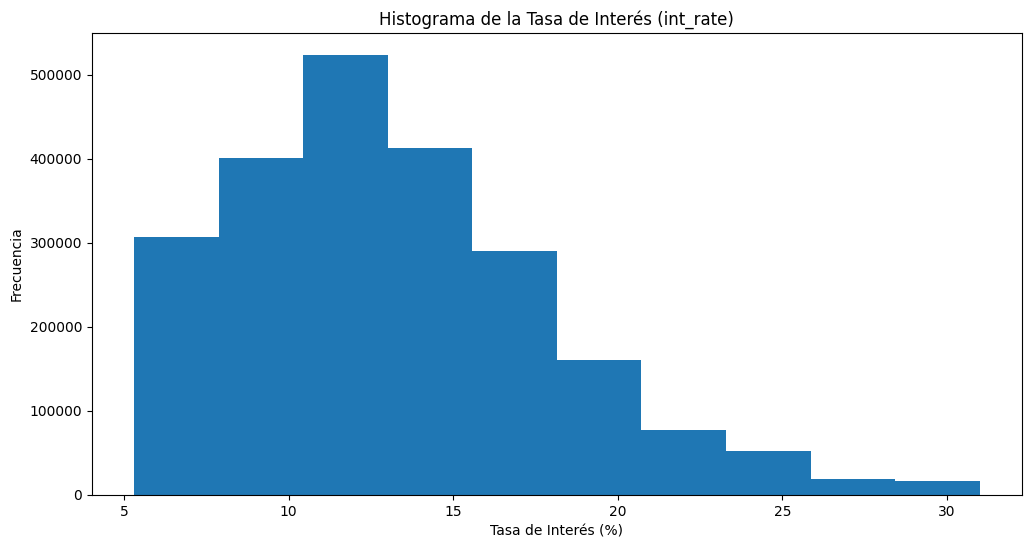

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.hist(df_va['int_rate'])  
plt.title("Histograma de la Tasa de Interés (int_rate)")
plt.xlabel("Tasa de Interés (%)")
plt.ylabel("Frecuencia")
plt.show()

A partir del histograma , la mayoria de prestamos cuentan con tasas de intereses que rondan entre el 10% y 12%. Por otra parte,se llegaron a obtener prestamos aproximadamente del 30% de tasa de interes.

#### **Prestamos por estados de Estados Unidos**

In [18]:
import plotly.graph_objects as go

casos_estado = df_va.groupby("addr_state").size().reset_index()
casos_estado.columns = ["addr_state", "cantidad"]

fig = go.Figure(
    data=go.Choropleth(
        locations=casos_estado["addr_state"],
        locationmode="USA-states",
        z=casos_estado["cantidad"],
        colorscale="Blues",
        colorbar_title="Cantidad de Préstamos",
        hovertemplate="<b>%{location}</b><br>Préstamos: %{z:,}<extra></extra>"
    )
)

fig.update_layout(
    title="Cantidad de Préstamos por Estado",
    geo_scope="usa",
    width=900,
    height=500
)

fig.show()

Con el mapa anterior se logra observar que la mayoria de prestamos se emiten en el estado de California teniendo mas de 300.000, seguidos por el estado de New York y Texas.

#### **Razones de Prestamo**

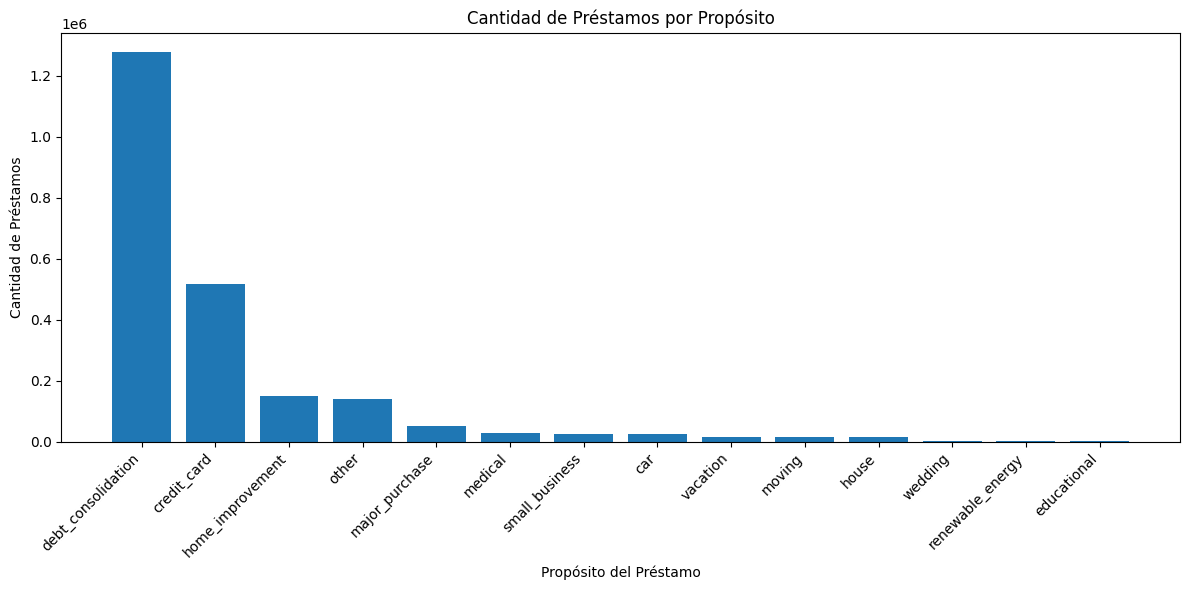

In [19]:
plt.figure(figsize=(12, 6))
plt.bar(df_va["purpose"].value_counts().index, df_va["purpose"].value_counts().values)
plt.title("Cantidad de Préstamos por Propósito")
plt.xlabel("Propósito del Préstamo")
plt.ylabel("Cantidad de Préstamos")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

La gran mayoria de usuarios piden prestamos a Lending Club con el fin de cubrir otras deudas. La segunda razon mas comun por la que se adquieren prestamos es para cubrir tarjetas de credito. 

### **calificacion de riesgo a prestamos aceptados**


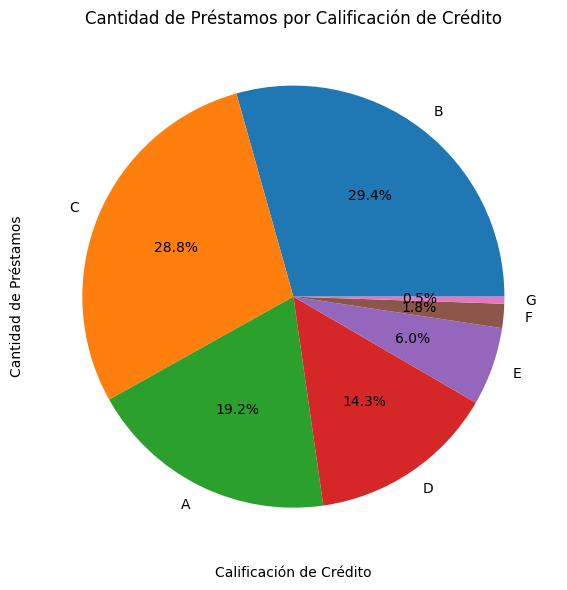

In [20]:
plt.figure(figsize=(12, 6))
plt.pie(df_va["grade"].value_counts().values, labels=df_va["grade"].value_counts().index, autopct='%1.1f%%')
plt.title("Cantidad de Préstamos por Calificación de Crédito")
plt.xlabel("Calificación de Crédito")
plt.ylabel("Cantidad de Préstamos")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

La gran mayoria de prestamos aceptados son otorgados a personas con una calificacion de B y C, llevandose casi el 60% de los casos. Mientras que tan solo el 2.4% constituyen a usuarios con una calificacion de G y F.

#### **Mapa Correlaciones**

In [21]:
variables_numericas = ['loan_amnt', 'int_rate', 'fico_range_high', 
                       'annual_inc', 'dti', 'installment', 'open_acc', 'default']

corr = df_va[variables_numericas].corr().round(2)

import plotly.express as px

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="RdBu_r",
    zmin=-1, zmax=1,
    title="Matriz de Correlación con Variable Objetivo (default)",
    width=800,
    height=700
)

fig.show()

La matriz de correlación evidencia una correlación positiva muy fuerte entre el monto del crédito y la cuota mensual, lo cual es evidente ya que a mayor monto solicitado, mayor será el pago mensual del prestatario. Asimismo, se observa una correlación negativa moderada entre el puntaje FICO y la tasa de interés, lo que significa que los solicitantes con mejor historial crediticio reciben tasas más bajas, ya que reflejan menor riesgo.

En cuanto a la variable objetivo default, no se evidencian correlaciones notorias con las variables numéricas analizadas. La mayor relacion es una leve correlación positiva con la tasa de interés, lo que sugiere que los préstamos con tasas más altas tienen una mayor probabilidad de no pagar.

### **Relacion entre el proposito y pago de credito**



In [22]:
import plotly.express as px

tasa = df_va.groupby('purpose')['default'].mean().mul(100).round(2).sort_values(ascending=False).reset_index()
tasa.columns = ['purpose', 'Tasa de pago incumplido (%)']

fig = px.bar(
    tasa,
    x='purpose',
    y='Tasa de pago incumplido (%)',
    title='Tasa de pago incumplido por Propósito del Préstamo',
    color='Tasa de pago incumplido (%)',
    color_continuous_scale='Blues',
    text='Tasa de pago incumplido (%)'
)

fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(xaxis_tickangle=-45, width=900, height=500)
fig.show()

El gráfico evidencia que los préstamos dirigidos a emprendimientos pequeños presentan la mayor tasa de incumplimiento, alcanzando un 18%, lo que es un alto riesgo  a este tipo de inversiones. Por otro lado, los préstamos para la compra de vehículo  presentan la menor tasa de incumplimiento con un 9.2%, lo que puede ser creditos mas fiables y menos riesgoso para Lending Club.

### **Relacion entre tipo de tenencia de hogar y cumplimiento de credito**

In [23]:
tasa = df_va.groupby('grade')['default'].mean().mul(100).round(2).sort_values(ascending=False).reset_index()
tasa.columns = ['grade', 'Tasa de pago incumplido (%)']

fig = px.bar(
    tasa,
    x='grade',
    y='Tasa de pago incumplido (%)',
    title='Tasa de pago incumplido por grado de riesgo',
    color='Tasa de pago incumplido (%)',
    color_continuous_scale='Blues',
    text='Tasa de pago incumplido (%)'
)

fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(xaxis_tickangle=-45, width=900, height=500)
fig.show()

Como era de esperarse, los préstamos otorgados a solicitantes con calificación G presentan la mayor tasa de incumplimiento con un 40%, seguidos por aquellos con calificación F con un 34.1%. En cambio, los préstamos con calificación A registran apenas un 3.3% de incumplimiento, lo que confirma que la calificación de riesgo asignada por Lending Club es un predictor clave.

## **Preprocesamiento Scikit Learn**

#### **Importacion de librerias**

In [24]:
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, classification_report, 
                             confusion_matrix)

#### **Seleccionamos target y demas variables**

In [25]:
if "default" not in df_va.columns:
    df_va["default"] = (df_va["loan_status"] == "Charged Off").astype(int)

features = ['loan_amnt', 'int_rate', 'fico_range_high', 'emp_length',
            'annual_inc', 'purpose', 'home_ownership', 'dti', 'addr_state',
            'grade', 'installment', 'open_acc']

target = "default"
features = [col for col in features if col in df_va.columns]
data = df_va[features + [target]].dropna().copy()

X = data[features]
y = data[target]

print(f"Shape X: {X.shape}")
print(f"Distribución target:\n{y.value_counts(normalize=True).mul(100).round(2)}")

Shape X: (2258928, 12)
Distribución target:
default
0    88.11
1    11.89
Name: proportion, dtype: float64


#### **Inicio de preprocesamiento Scikit-learn**

In [26]:
num_cols = [col for col in ["loan_amnt", "int_rate", "fico_range_high", "annual_inc", 
                             "dti", "installment", "open_acc"] if col in X.columns]
cat_cols = [col for col in ["emp_length", "purpose", "home_ownership", 
                             "addr_state", "grade"] if col in X.columns]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

print(f"Variables numéricas: {num_cols}")
print(f"Variables categóricas: {cat_cols}")

Variables numéricas: ['loan_amnt', 'int_rate', 'fico_range_high', 'annual_inc', 'dti', 'installment', 'open_acc']
Variables categóricas: ['emp_length', 'purpose', 'home_ownership', 'addr_state', 'grade']


#### **Division (80/20) train/ test**

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Distribución train:\n{y_train.value_counts(normalize=True).mul(100).round(2)}")
print(f"Distribución test:\n{y_test.value_counts(normalize=True).mul(100).round(2)}")

Train: (1807142, 12) | Test: (451786, 12)
Distribución train:
default
0    88.11
1    11.89
Name: proportion, dtype: float64
Distribución test:
default
0    88.11
1    11.89
Name: proportion, dtype: float64


#### **Aplicacion de GridSearchCV**

El GridSearchCV evalua  todas las combinaciones posibles de hiperparámetros definidas, resultando en este caso 9 combinaciones resultantes de cruzar 3 valores de n_estimators (10, 50, 100) con 3 valores de max_depth (5, 10, 15). Para cada combinación se divide el conjunto de entrenamiento en 3 partes, entrena con 2 y valida con 1, rotando hasta cubrir todas las partes. Esto resulta en 27 modelos entrenados en total, al final de los cuales se va a seleccionar  la combinación con mejor ROC-AUC promedio.

## **Evaluacion Scikit-Learn**

**A continuacion se van a evaluar las metricas para determinar si el modelo es correcto usando los mejores hiperparametros**

In [25]:
mejor_modelo = grid_search.best_estimator_

start_pred = time.time()
y_pred = mejor_modelo.predict(X_test_prep)
t_pred = time.time() - start_pred

y_prob = mejor_modelo.predict_proba(X_test_prep)[:, 1]

print(f"Tiempo de predicción: {t_pred:.2f} segundos")
print("\n======== MÉTRICAS RANDOM FOREST ========")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

NameError: name 'grid_search' is not defined

======== RANDOM FOREST ========
Accuracy: 0.5960963819153315
ROC-AUC: 0.7054958594245939

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.94      0.58      0.72    398088
           1       0.19      0.71      0.29     53698

    accuracy                           0.60    451786
   macro avg       0.56      0.65      0.51    451786
weighted avg       0.85      0.60      0.67    451786



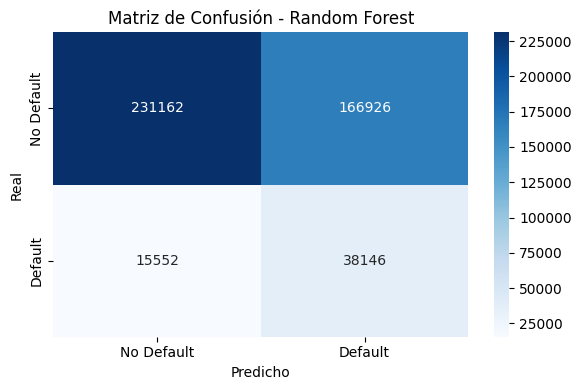

Verdaderos Negativos (TN): 231162
Falsos Positivos  (FP):    166926
Falsos Negativos  (FN):    15552
Verdaderos Positivos (TP): 38146


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# =========================
# 0. Asegurar target
# =========================
if "default" not in df_va.columns:
    df_va["default"] = (df_va["loan_status"] == "Charged Off").astype(int)

# =========================
# 1. Seleccionar variables relevantes
# =========================
features = [
    'loan_amnt', 'int_rate', 'fico_range_high', 'emp_length',
    'annual_inc', 'purpose', 'home_ownership', 'dti', 'addr_state',
    'grade', 'installment', 'open_acc'
]

target = "default"
features = [col for col in features if col in df_va.columns]
data = df_va[features + [target]].copy()

# =========================
# 2. Separar X e y
# =========================
X = data[features]
y = data[target]

# =========================
# 3. Variables numéricas y categóricas
# =========================
num_cols = [col for col in ["loan_amnt", "int_rate", "fico_range_high", "annual_inc", "dti", "installment", "open_acc"] if col in X.columns]
cat_cols = [col for col in ["emp_length", "purpose", "home_ownership", "addr_state", "grade"] if col in X.columns]

# =========================
# 4. Preprocesamiento
# =========================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

# =========================
# 5. División train/test
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# Función matriz de confusión
# =========================
def plot_confusion_matrix(y_test, y_pred, titulo):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'])
    plt.title(titulo)
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.tight_layout()
    plt.show()
    print(f"Verdaderos Negativos (TN): {cm[0,0]}")
    print(f"Falsos Positivos  (FP):    {cm[0,1]}")
    print(f"Falsos Negativos  (FN):    {cm[1,0]}")
    print(f"Verdaderos Positivos (TP): {cm[1,1]}")

# =========================
# 6. Modelo Random Forest
# =========================
modelo_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

print("======== RANDOM FOREST ========")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf))
plot_confusion_matrix(y_test, y_pred_rf, "Matriz de Confusión - Random Forest")

### **Pyspark**

In [29]:
import os
import sys
import subprocess

# Esto intenta ubicar el java del env conda
java_path = os.path.join(sys.prefix, "Library", "bin", "java.exe")
if os.path.exists(java_path):
    os.environ["JAVA_HOME"] = os.path.join(sys.prefix, "Library")
    os.environ["PATH"] = os.path.join(sys.prefix, "Library", "bin") + ";" + os.environ["PATH"]

print("JAVA_HOME =", os.environ.get("JAVA_HOME"))
print(subprocess.check_output(["java", "-version"], stderr=subprocess.STDOUT).decode("utf-8"))

JAVA_HOME = c:\Users\leste\anaconda3\envs\miniproyecto1_ml\Library
openjdk version "25.0.2" 2026-01-20 LTS
OpenJDK Runtime Environment Zulu25.32+21-CA (build 25.0.2+10-LTS)
OpenJDK 64-Bit Server VM Zulu25.32+21-CA (build 25.0.2+10-LTS, mixed mode, sharing)



In [43]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("LendingClub_Default_PySpark")
    .config("spark.sql.shuffle.partitions", "200")
    .getOrCreate()
)

spark

In [44]:
print("Filas:", df_va.shape[0])
print("Columnas:", df_va.shape[1])

status_counts = (
    df_va.groupby("loan_status")
         .size()
         .reset_index(name="count")
         .sort_values("count", ascending=False)
)

print(status_counts.head(10))

Filas: 2258928
Columnas: 93
                                           loan_status    count
5                                           Fully Paid  1076448
1                                              Current   877018
0                                          Charged Off   268488
8                                   Late (31-120 days)    21443
6                                      In Grace Period     8427
7                                    Late (16-30 days)     4344
4   Does not meet the credit policy. Status:Fully Paid     1962
3  Does not meet the credit policy. Status:Charged Off      758
2                                              Default       40


In [45]:
# Caso estándar LendingClub: loan_status
if "loan_status" in df_va.columns:
    df = df_va[df_va["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()
    df["label"] = (df["loan_status"] == "Charged Off").astype(int)

else:
    # Plan B: si existe columna "default"
    if "default" in df_va.columns:

        default_clean = (
            df_va["default"]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        df = df_va.copy()
        df["label"] = None

        df.loc[default_clean.isin(["1","Y","YES","TRUE","T"]), "label"] = 1
        df.loc[default_clean.isin(["0","N","NO","FALSE","F"]), "label"] = 0

        df = df[df["label"].notna()].copy()
        df["label"] = df["label"].astype(int)

    else:
        raise ValueError("No se encontró ni 'loan_status' ni 'default' para crear label.")

# equivalente a groupBy().count()
print(df["label"].value_counts())

label
0    1076448
1     268488
Name: count, dtype: int64


In [46]:
import pandas as pd
import numpy as np

# Lista de features
num_cols = [
    "loan_amnt", "funded_amnt", "funded_amnt_inv",
    "int_rate", "installment",
    "annual_inc", "dti",
    "fico_range_low", "fico_range_high"
]

cat_cols = [
    "term", "grade", "home_ownership", "verification_status", "purpose", "addr_state"
]

# Solo quedarnos con columnas que existan
num_cols = [c for c in num_cols if c in df.columns]
cat_cols = [c for c in cat_cols if c in df.columns]

keep_cols = num_cols + cat_cols + ["label"]
if "loan_status" in df.columns:
    keep_cols += ["loan_status"]

df = df[keep_cols].copy()

# ---- LIMPIEZA ROBUSTA DE COLUMNAS NUMÉRICAS ----
for c in num_cols:
    df[c] = (
        df[c]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
        .replace("", np.nan)
    )
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ---- PESOS PARA BALANCEO ----
counts = df["label"].value_counts().to_dict()

n0 = counts.get(0, 1)
n1 = counts.get(1, 1)
total = n0 + n1

w0 = total / (2.0 * n0)
w1 = total / (2.0 * n1)

df["weight"] = df["label"].apply(lambda x: w1 if x == 1 else w0)

print("n0:", n0, "n1:", n1)
print("w0:", w0, "w1:", w1)

print(
    df.groupby(["label", "weight"])
      .size()
      .reset_index(name="count")
)

n0: 1076448 n1: 268488
w0: 0.6247101578524926 w1: 2.504648252435863
   label    weight    count
0      0  0.624710  1076448
1      1  2.504648   268488


Creacion de pipeline

In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# Quitar columnas que NO deben entrar al modelo
cols_to_drop = ["label", "loan_status", "weight"]
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

X = df.drop(columns=cols_to_drop).copy()
y = df["label"].copy()

# Detectar columnas numéricas y categóricas
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

# Transformador para variables numéricas
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Transformador para variables categóricas
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocesamiento completo
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

# Pipeline final
pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

print("Pipeline construido correctamente")

Numéricas: ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'fico_range_low', 'fico_range_high']
Categóricas: ['term', 'grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state']
Pipeline construido correctamente


Quitar fuga de informacion

In [48]:
import pandas as pd

# eliminar columnas que fugan la respuesta
cols_to_drop = ["label", "loan_status"]
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

X = df.drop(columns=cols_to_drop).copy()
y = df["label"].copy()

print("Columnas usadas para entrenar:")
print(X.columns.tolist())
print("\n¿Está loan_status en X?", "loan_status" in X.columns)

Columnas usadas para entrenar:
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'fico_range_low', 'fico_range_high', 'term', 'grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'weight']

¿Está loan_status en X? False


In [50]:
import time
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# Separar variables de entrada y objetivo
X = df.drop(columns=["label", "loan_status", "weight"], errors="ignore").copy()
y = df["label"].copy()

# Detectar columnas numéricas y categóricas
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

# Preprocesamiento
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

# Pipeline con modelo más liviano
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Entrenamiento
t0 = time.time()
pipeline.fit(X_train, y_train)
train_time = time.time() - t0

# Predicción
t1 = time.time()
pred_labels = pipeline.predict(X_test)
probs = pipeline.predict_proba(X_test)
pred_time = time.time() - t1

print(f"Tiempo entrenamiento: {train_time:.2f} s")
print(f"Tiempo predicción:    {pred_time:.2f} s")

# Resultados
result = X_test.copy()
result["label"] = y_test.values
result["prediction"] = pred_labels
result["probability_0"] = probs[:, 0]
result["probability_1"] = probs[:, 1]

print(result[["label", "prediction", "probability_0", "probability_1"]].head(10))

Tiempo entrenamiento: 127.50 s
Tiempo predicción:    2.53 s
         label  prediction  probability_0  probability_1
2009507      0           0       0.591064       0.408936
1729214      0           0       0.847716       0.152284
667494       0           1       0.439000       0.561000
1816304      0           0       0.590138       0.409862
1976253      0           1       0.495587       0.504413
399416       0           0       0.788546       0.211454
297564       0           1       0.469692       0.530308
647315       0           0       0.569377       0.430623
137906       0           0       0.640087       0.359913
1206220      0           1       0.339432       0.660568


In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("Accuracy :", accuracy_score(y_test, pred_labels))
print("Precision:", precision_score(y_test, pred_labels, zero_division=0))
print("Recall   :", recall_score(y_test, pred_labels, zero_division=0))
print("F1-score :", f1_score(y_test, pred_labels, zero_division=0))
print("ROC AUC  :", roc_auc_score(y_test, probs[:, 1]))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, pred_labels))

Accuracy : 0.6300615640846432
Precision: 0.3075831016204501
Recall   : 0.6818689709113933
F1-score : 0.4239343749819091
ROC AUC  : 0.7069761991219862

Matriz de confusión:
[[132864  82426]
 [ 17083  36615]]


In [52]:
import numpy as np

# usar probabilidades del modelo
pred = result.copy()
pred["p1"] = pred["probability_1"]

thresholds = [0.50, 0.30, 0.20, 0.15, 0.10, 0.05]

def eval_threshold(TH):
    
    tmp = pred.copy()
    tmp["pred_thr"] = np.where(tmp["p1"] >= TH, 1, 0)

    tp = ((tmp["label"]==1) & (tmp["pred_thr"]==1)).sum()
    tn = ((tmp["label"]==0) & (tmp["pred_thr"]==0)).sum()
    fp = ((tmp["label"]==0) & (tmp["pred_thr"]==1)).sum()
    fn = ((tmp["label"]==1) & (tmp["pred_thr"]==0)).sum()

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2*precision*recall/(precision+recall) if (precision+recall) else 0
    acc = (tp+tn) / (tp+tn+fp+fn) if (tp+tn+fp+fn) else 0

    return (TH, acc, precision, recall, f1, tp, fp, fn, tn)


results = [eval_threshold(th) for th in thresholds]

print("TH | Acc | Prec | Rec | F1 | TP FP FN TN")
for r in results:
    print(f"{r[0]:.2f} | {r[1]:.4f} | {r[2]:.4f} | {r[3]:.4f} | {r[4]:.4f} | {r[5]} {r[6]} {r[7]} {r[8]}")


# elegir threshold final
TH = 0.15
pred["pred_thr"] = np.where(pred["p1"] >= TH, 1, 0)

print("\nPredicciones con threshold final:")
print(pred[["label","p1","pred_thr"]].head(10))

TH | Acc | Prec | Rec | F1 | TP FP FN TN
0.50 | 0.6301 | 0.3076 | 0.6819 | 0.4239 | 36615 82426 17083 132864
0.30 | 0.3548 | 0.2300 | 0.9509 | 0.3705 | 51064 170920 2634 44370
0.20 | 0.2599 | 0.2113 | 0.9905 | 0.3483 | 53190 198560 508 16730
0.15 | 0.2142 | 0.2024 | 0.9987 | 0.3366 | 53627 211312 71 3978
0.10 | 0.1996 | 0.1996 | 1.0000 | 0.3328 | 53698 215290 0 0
0.05 | 0.1996 | 0.1996 | 1.0000 | 0.3328 | 53698 215290 0 0

Predicciones con threshold final:
         label        p1  pred_thr
2009507      0  0.408936         1
1729214      0  0.152284         1
667494       0  0.561000         1
1816304      0  0.409862         1
1976253      0  0.504413         1
399416       0  0.211454         1
297564       0  0.530308         1
647315       0  0.430623         1
137906       0  0.359913         1
1206220      0  0.660568         1


In [53]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, probs[:, 1])
print("ROC-AUC:", auc)

ROC-AUC: 0.7069761991219862


Interpretabilidad de LIME

In [54]:
import numpy as np
import pandas as pd

# Predicciones del mejor modelo / pipeline
pred_labels = pipeline.predict(X_test)
probs = pipeline.predict_proba(X_test)

# DataFrame de resultados
lime_results = X_test.copy()
lime_results["label"] = y_test.values
lime_results["prediction"] = pred_labels
lime_results["probability_1"] = probs[:, 1]

# Casos mal clasificados
wrong_preds = lime_results[lime_results["label"] != lime_results["prediction"]].copy()

print("Número de errores:", len(wrong_preds))
print(wrong_preds[["label", "prediction", "probability_1"]].head(10))

Número de errores: 99509
         label  prediction  probability_1
667494       0           1       0.561000
1976253      0           1       0.504413
297564       0           1       0.530308
1206220      0           1       0.660568
1945945      1           0       0.321454
1305249      0           1       0.610972
1778315      0           1       0.563339
1900116      1           0       0.430147
1795232      0           1       0.769610
1865761      0           1       0.612547


In [56]:
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import HTML
import numpy as np
import pandas as pd

# 1) Separar preprocesador y modelo del pipeline
prep = pipeline.named_steps["preprocessor"]
model = pipeline.named_steps["model"]

# 2) Transformar train y test a matriz numérica
X_train_prep = prep.transform(X_train)
X_test_prep = prep.transform(X_test)

# 3) Nombres de features transformadas
feature_names = prep.get_feature_names_out()

# 4) Función de predicción para LIME
def predict_fn(x):
    return model.predict_proba(x)

# 5) Crear explicador LIME sobre datos numéricos ya transformados
explainer = LimeTabularExplainer(
    training_data=X_train_prep,
    feature_names=feature_names,
    class_names=["Fully Paid", "Charged Off"],
    mode="classification"
)

# 6) Buscar casos mal clasificados
pred_labels = pipeline.predict(X_test)
probs = pipeline.predict_proba(X_test)

wrong_idx = np.where(y_test.values != pred_labels)[0]

print("Número de errores:", len(wrong_idx))

# 7) Explicar el primer error
i = wrong_idx[0]

exp = explainer.explain_instance(
    data_row=X_test_prep[i],
    predict_fn=predict_fn,
    num_features=10
)

print("Label real:", y_test.iloc[i])
print("Predicción:", pred_labels[i])
print("Probabilidad clase 1:", probs[i, 1])

print("\nVariables más influyentes:")
for item in exp.as_list():
    print(item)

HTML(exp.as_html())

Número de errores: 99509
Label real: 0
Predicción: 1
Probabilidad clase 1: 0.5610003221938006

Variables más influyentes:
('num__funded_amnt', 0.0)
('num__funded_amnt_inv', 0.0)
('num__int_rate', 0.0)
('num__installment', 0.0)
('num__annual_inc', 0.0)
('num__dti', 0.0)
('num__fico_range_low', 0.0)
('num__fico_range_high', 0.0)
('cat__term_ 36 months', 0.0)
('cat__term_ 60 months', 0.0)


In [57]:
# elegir una observación mal clasificada
idx = wrong_preds.index[0]

x_instance = X_test.loc[idx].values
true_label = y_test.loc[idx]
pred_label = pred_labels[list(X_test.index).index(idx)]
pred_prob = probs[list(X_test.index).index(idx), 1]

print("Índice:", idx)
print("Label real:", true_label)
print("Predicción:", pred_label)
print("Probabilidad clase 1:", pred_prob)

Índice: 667494
Label real: 0
Predicción: 1
Probabilidad clase 1: 0.5610003221938006


In [59]:
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import HTML
import numpy as np

# separar preprocesador y modelo
prep = pipeline.named_steps["preprocessor"]
model = pipeline.named_steps["model"]

# transformar train y test
X_train_prep = prep.transform(X_train)
X_test_prep = prep.transform(X_test)

# si quedan sparse matrices, convertir a array
if hasattr(X_train_prep, "toarray"):
    X_train_prep = X_train_prep.toarray()

if hasattr(X_test_prep, "toarray"):
    X_test_prep = X_test_prep.toarray()

# nombres de variables transformadas
feature_names = prep.get_feature_names_out()

# crear explicador
explainer = LimeTabularExplainer(
    training_data=X_train_prep,
    feature_names=feature_names,
    class_names=["Fully Paid", "Charged Off"],
    mode="classification"
)

# función de predicción para LIME
def predict_fn(x):
    return model.predict_proba(x)

# elegir una observación
i = 0
x_instance = X_test_prep[i]

# explicar
exp = explainer.explain_instance(
    data_row=x_instance,
    predict_fn=predict_fn,
    num_features=10
)

# mostrar en notebook
HTML(exp.as_html())